# Campaign evaluation (multiple files)

Compare every run of a measurement campaign side by side. The notebook **auto-discovers** all runs in a campaign folder, builds a summary table, shows a per-run overview, and overlays the runs on the comparison grids. Labels/titles are filled from each file's own metadata (filter | polarisation | power).

> To analyse a single file in depth, use `main_scratchpad2.ipynb`.

In [ ]:
import numpy as np
from pathlib import Path
import sys 
import os

project_root = os.path.abspath('..')

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.hbt_core import HBTMeasurement
from src.hbt_visu import GridVisualizer

## 1. Point at the campaign

Set `CAMPAIGN_DIR` to the folder holding the runs. Every sub-folder ending in `g2_heralded_virtual` that contains a `*chunk0.pkl` is picked up automatically.

In [2]:
CAMPAIGN_DIR = Path("data/Jun15")

run_files = sorted(CAMPAIGN_DIR.glob("*g2_heralded_virtual/MERGED/*_MERGED.pkl"))
if not run_files:
    run_files = sorted(CAMPAIGN_DIR.glob("*g2_heralded_virtual/*chunk0.pkl"))
assert run_files, f"No runs found under {CAMPAIGN_DIR}"

runs = [HBTMeasurement(f) for f in run_files]
print(f"Discovered {len(runs)} run(s) in {CAMPAIGN_DIR}:")
for r in runs:
    print(f"*---------------------- \n{r.acquisition_summary()}\n{r.acquisition_details()}\nphysical histograms: {r.has_physical_histograms}\n")

Discovered 2 run(s) in data/Jun15:
*---------------------- 
Sample: CdTe110  |  $\lambda_L = 2100$ nm  |  $P = 40.7$ mW  |  $f_{rep} = 18.88$ MHz  |  Filter: 700/10 nm  |  Pol. P1
bin $= 100$ ps  |  coinc. window $= 25$ ns  |  $T_{acq} = 60$ s  |  stage $= 292$  |  2026-06-15
physical histograms: True

*---------------------- 
Sample: CdTe110  |  $\lambda_L = 2100$ nm  |  $P = 40.7$ mW  |  $f_{rep} = 18.88$ MHz  |  Filter: 700/40 nm  |  Pol. P1
bin $= 100$ ps  |  coinc. window $= 25$ ns  |  $T_{acq} = 180$ s  |  stage $= 292$  |  2026-06-15
physical histograms: True



## 2. Summary table

Physical $g^{(2)}(0)$ (direct method) for the three auto-correlations and the cross-correlations, plus the
Cauchy–Schwarz $R$ for each harmonic pair. One row per run.

In [3]:
def auto(r, h):   return r.compute_g2_direct(r.get_ch(f"H{h}T"), r.get_ch(f"H{h}R"))
def cross(r, a, b): return r.compute_g2_direct(r.get_ch(f"H{a}T"), r.get_ch(f"H{b}T"))
def Rpar(r, a, b):  return r.compute_R_parameter(cross(r, a, b), auto(r, a), auto(r, b))

hdr = (f"{'dataset':34s}" + "".join(f"{c:>9s}" for c in
       ["g2_33","g2_44","g2_55","g2_34","g2_35","g2_45","R_34","R_35","R_45"]))
print(hdr); print("-"*len(hdr))

for r in runs:
    vals = [auto(r,3),auto(r,4),auto(r,5), cross(r,3,4),cross(r,3,5),cross(r,4,5),
            Rpar(r,3,4),Rpar(r,3,5),Rpar(r,4,5)]
    print(f"{r.short_tag():34s}" + "".join(f"{v:9.3f}" for v in vals))

dataset                               g2_33    g2_44    g2_55    g2_34    g2_35    g2_45     R_34     R_35     R_45
-------------------------------------------------------------------------------------------------------------------
700/10 nm | Pol. P1 | 40.7 mW         1.394    1.165    1.185    1.214    1.221    1.176    0.908    0.902    1.001
700/40 nm | Pol. P1 | 40.7 mW         0.489    0.505    0.517    0.500    0.505    0.512    1.014    1.005    1.002


## 3. Per-run overview

For each run, the coherence matrix and the physical $g^{(2)}$ matrix. The `delay` method is physical when the
run carries per-detector histograms and virtual otherwise (it is labelled accordingly).

RUN: 700/10 nm | Pol. P1 | 40.7 mW


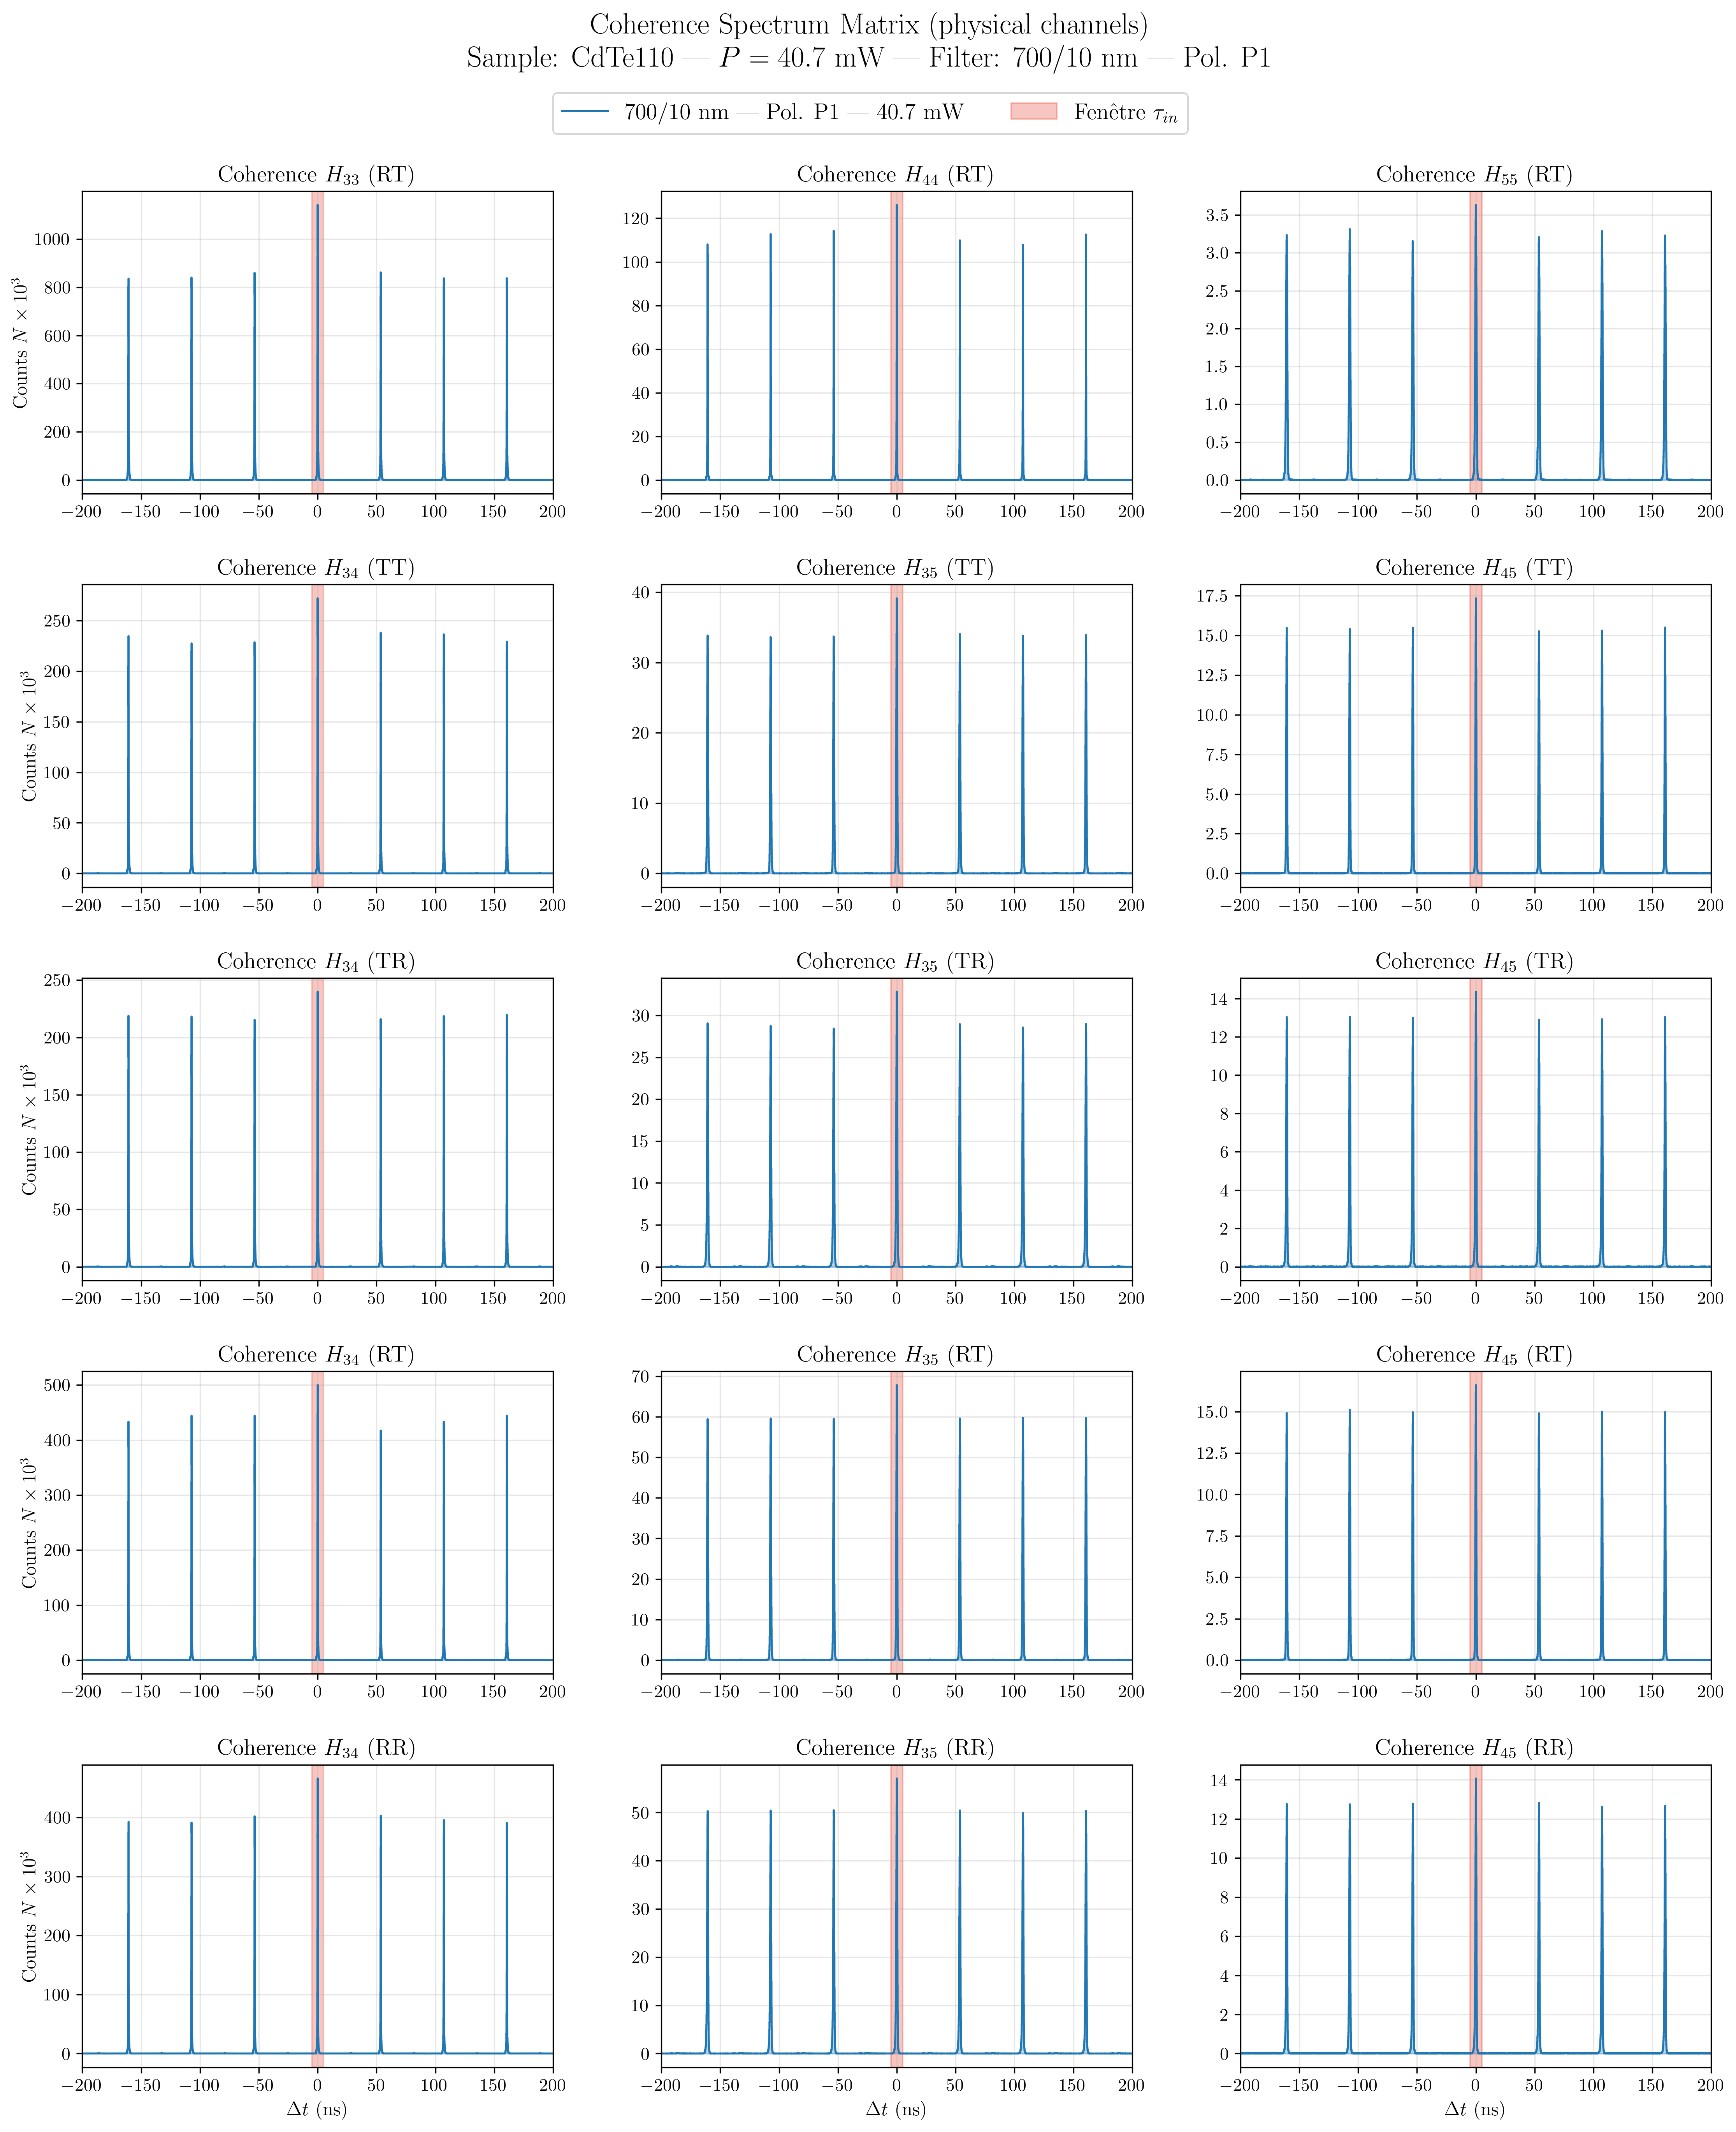

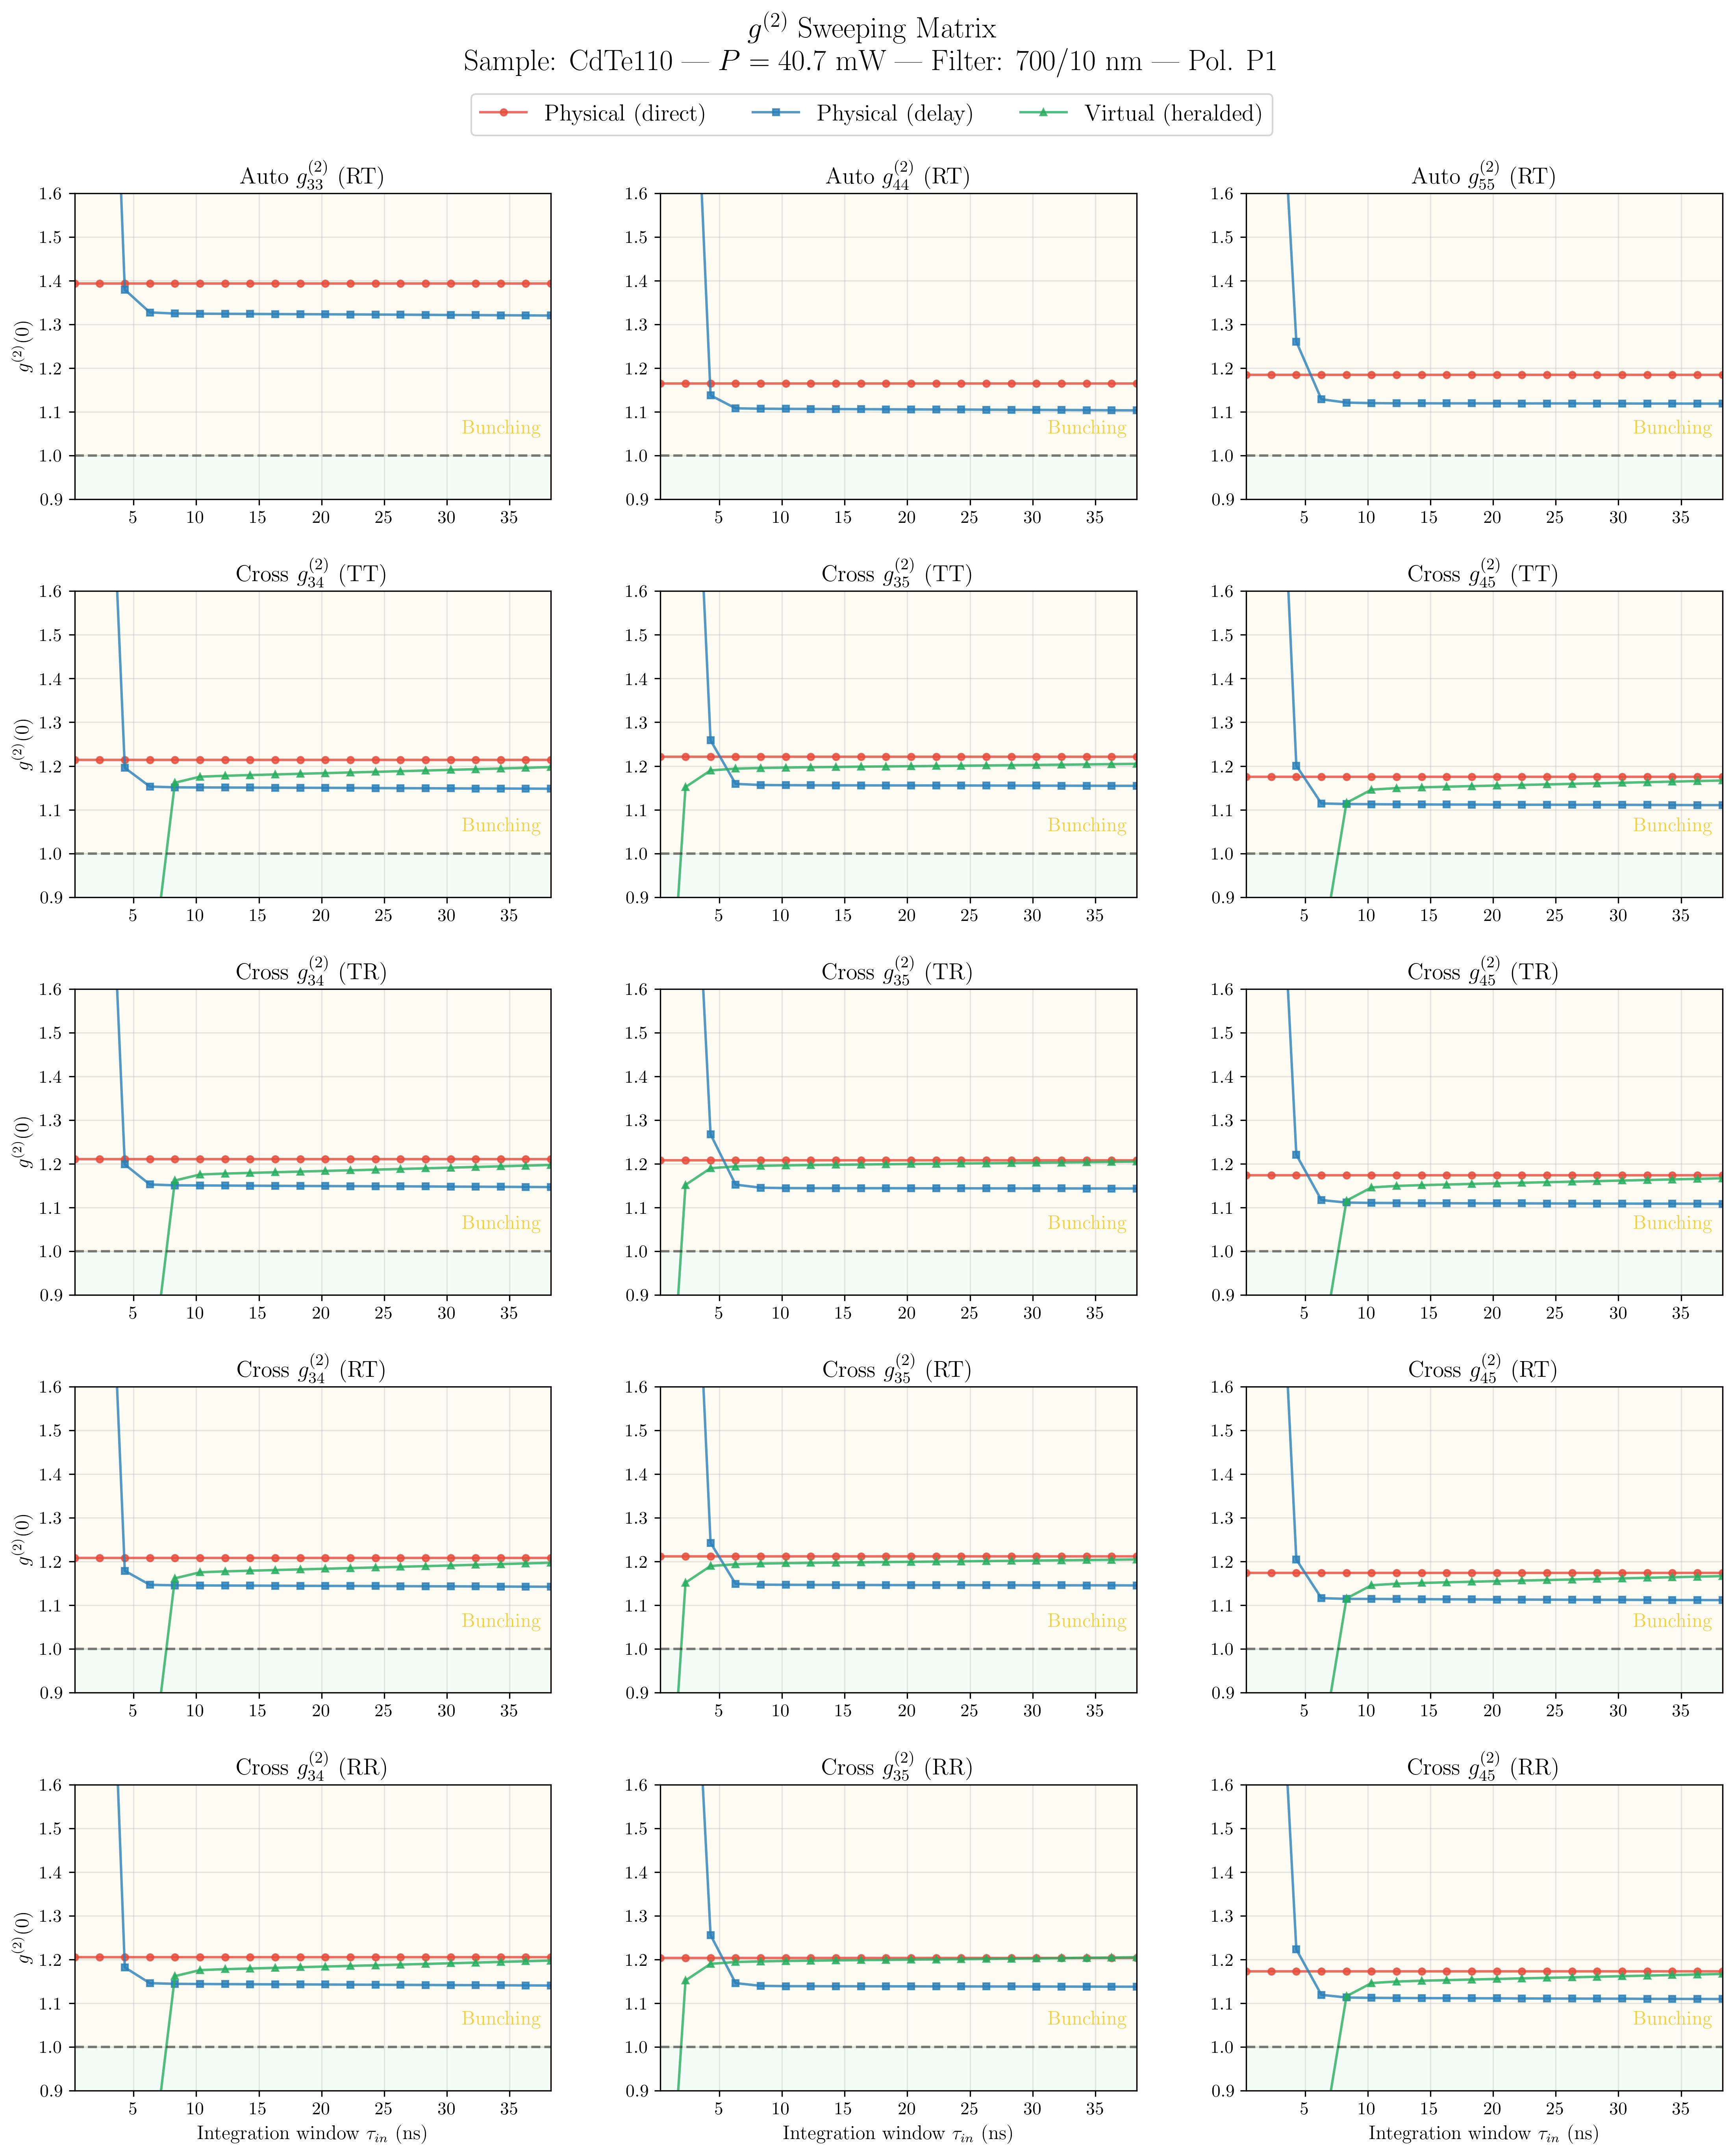

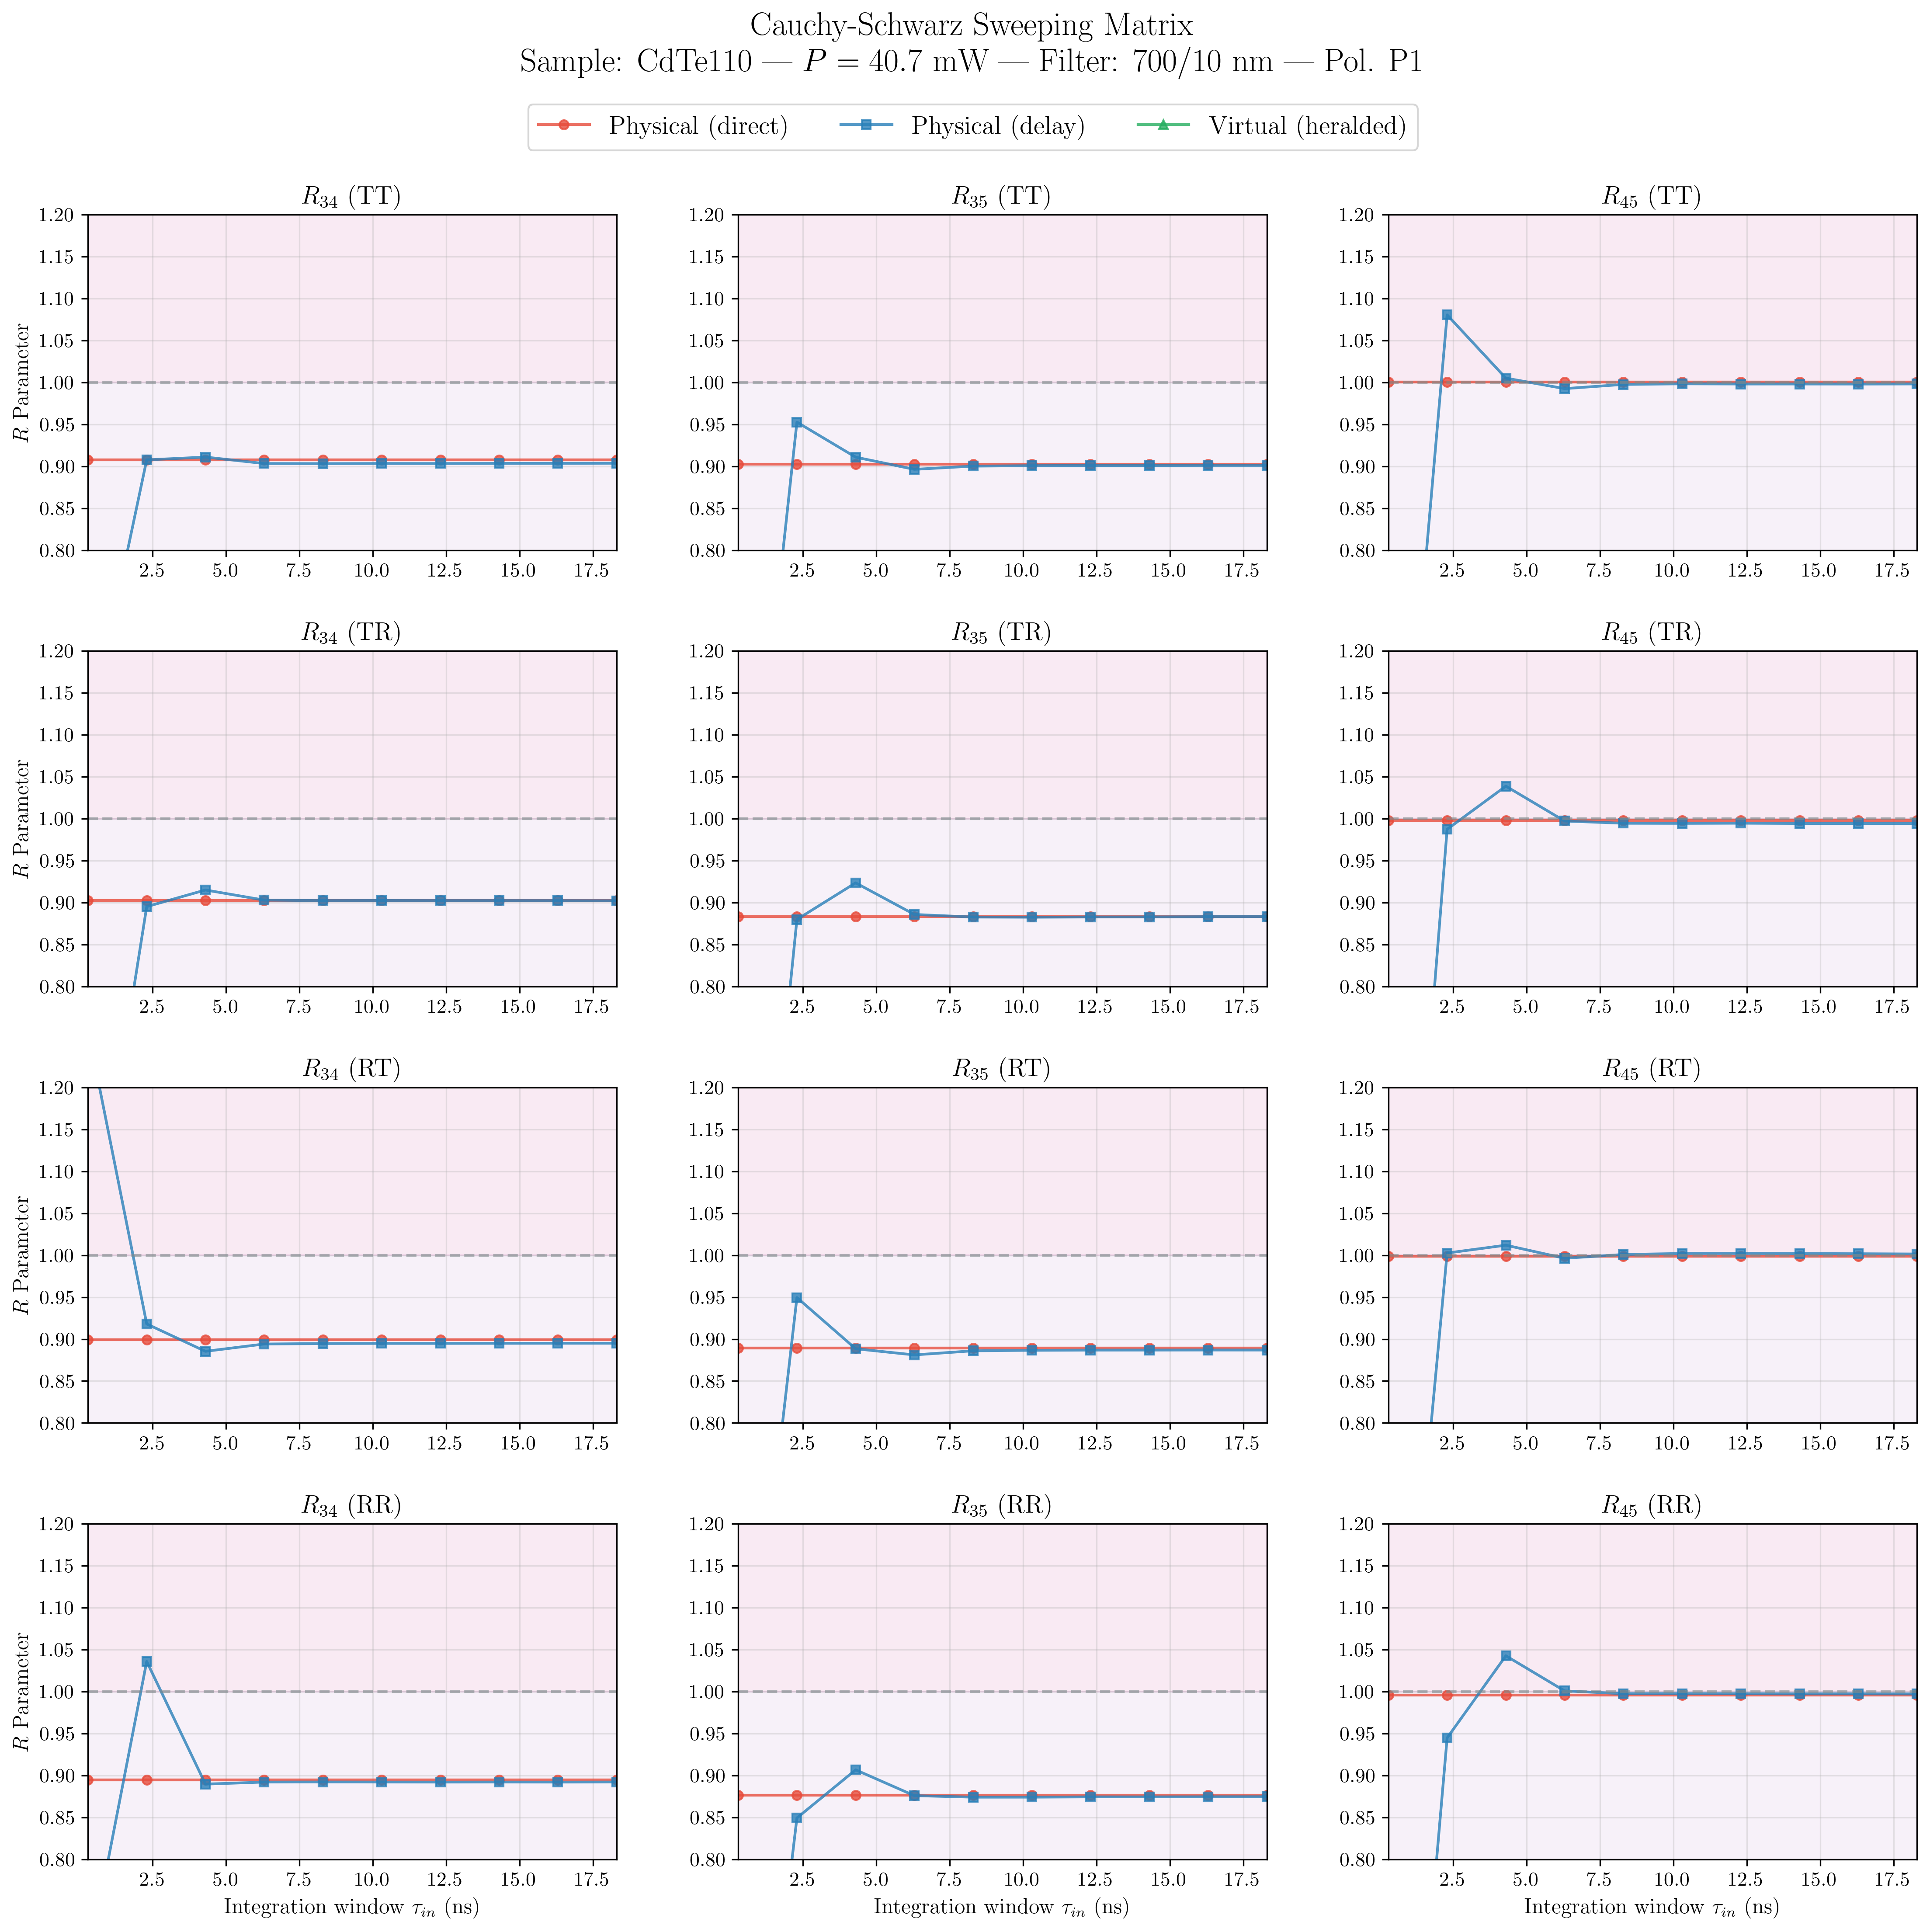

RUN: 700/40 nm | Pol. P1 | 40.7 mW


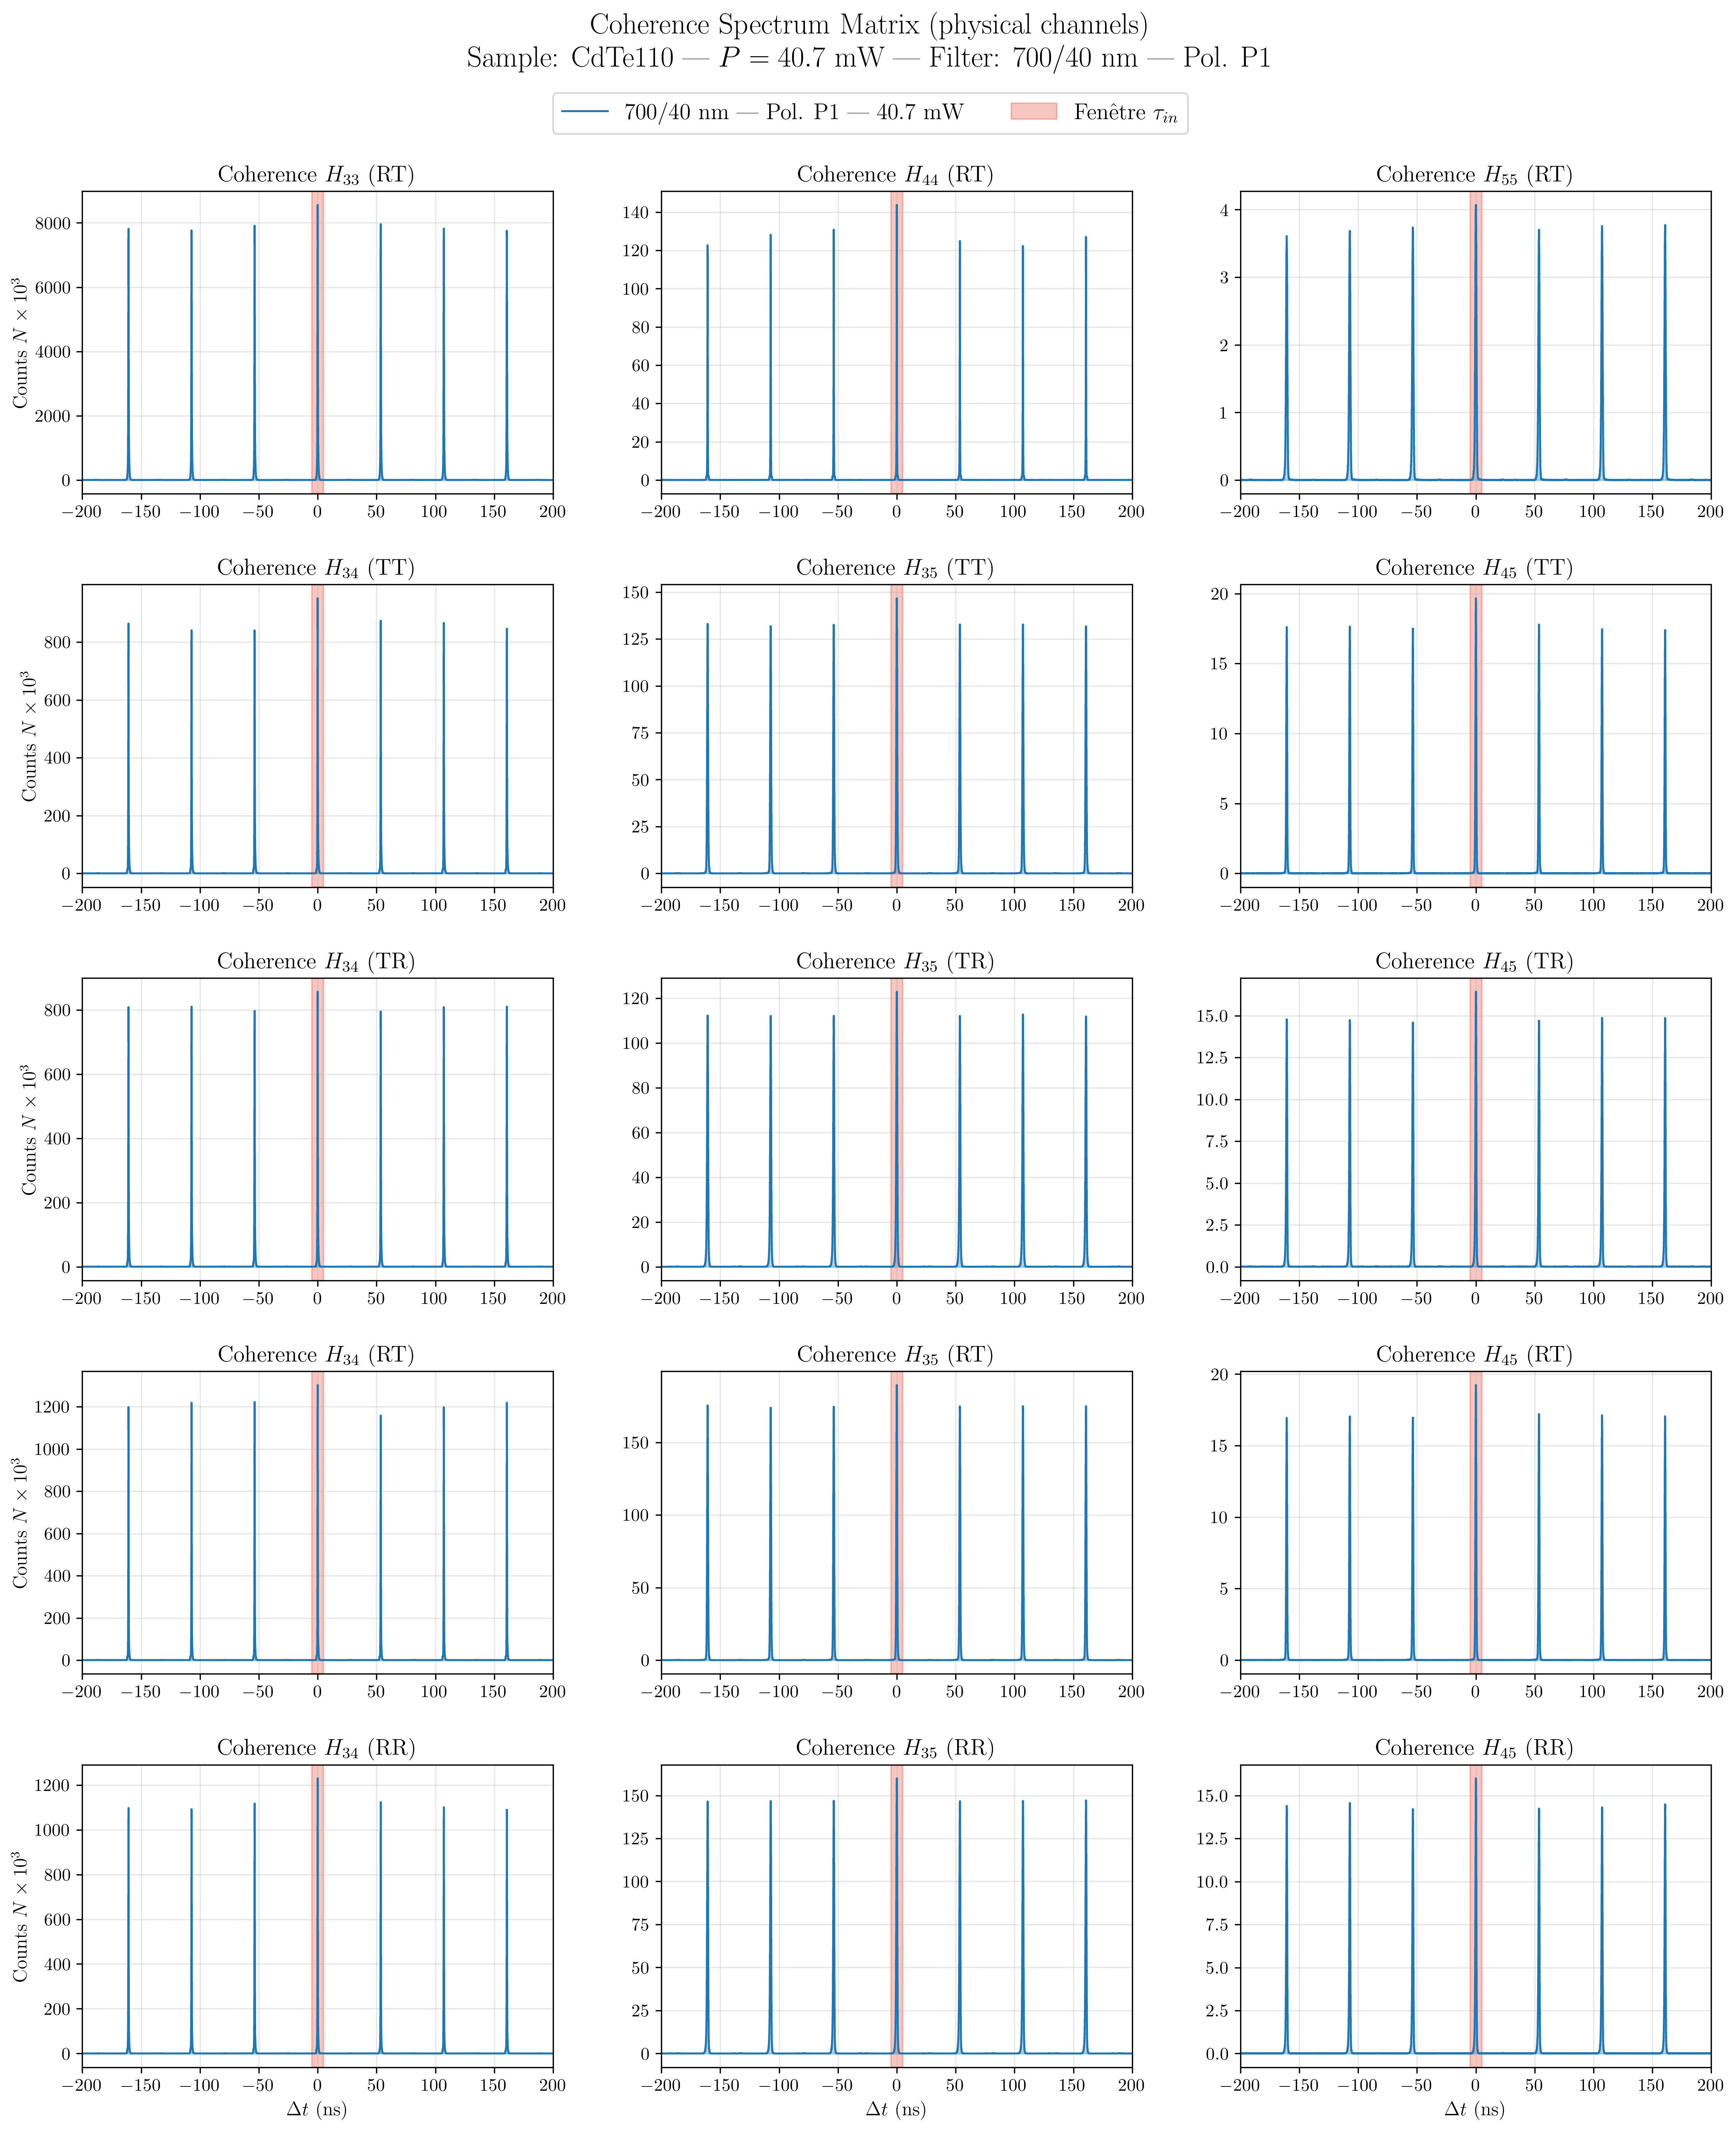

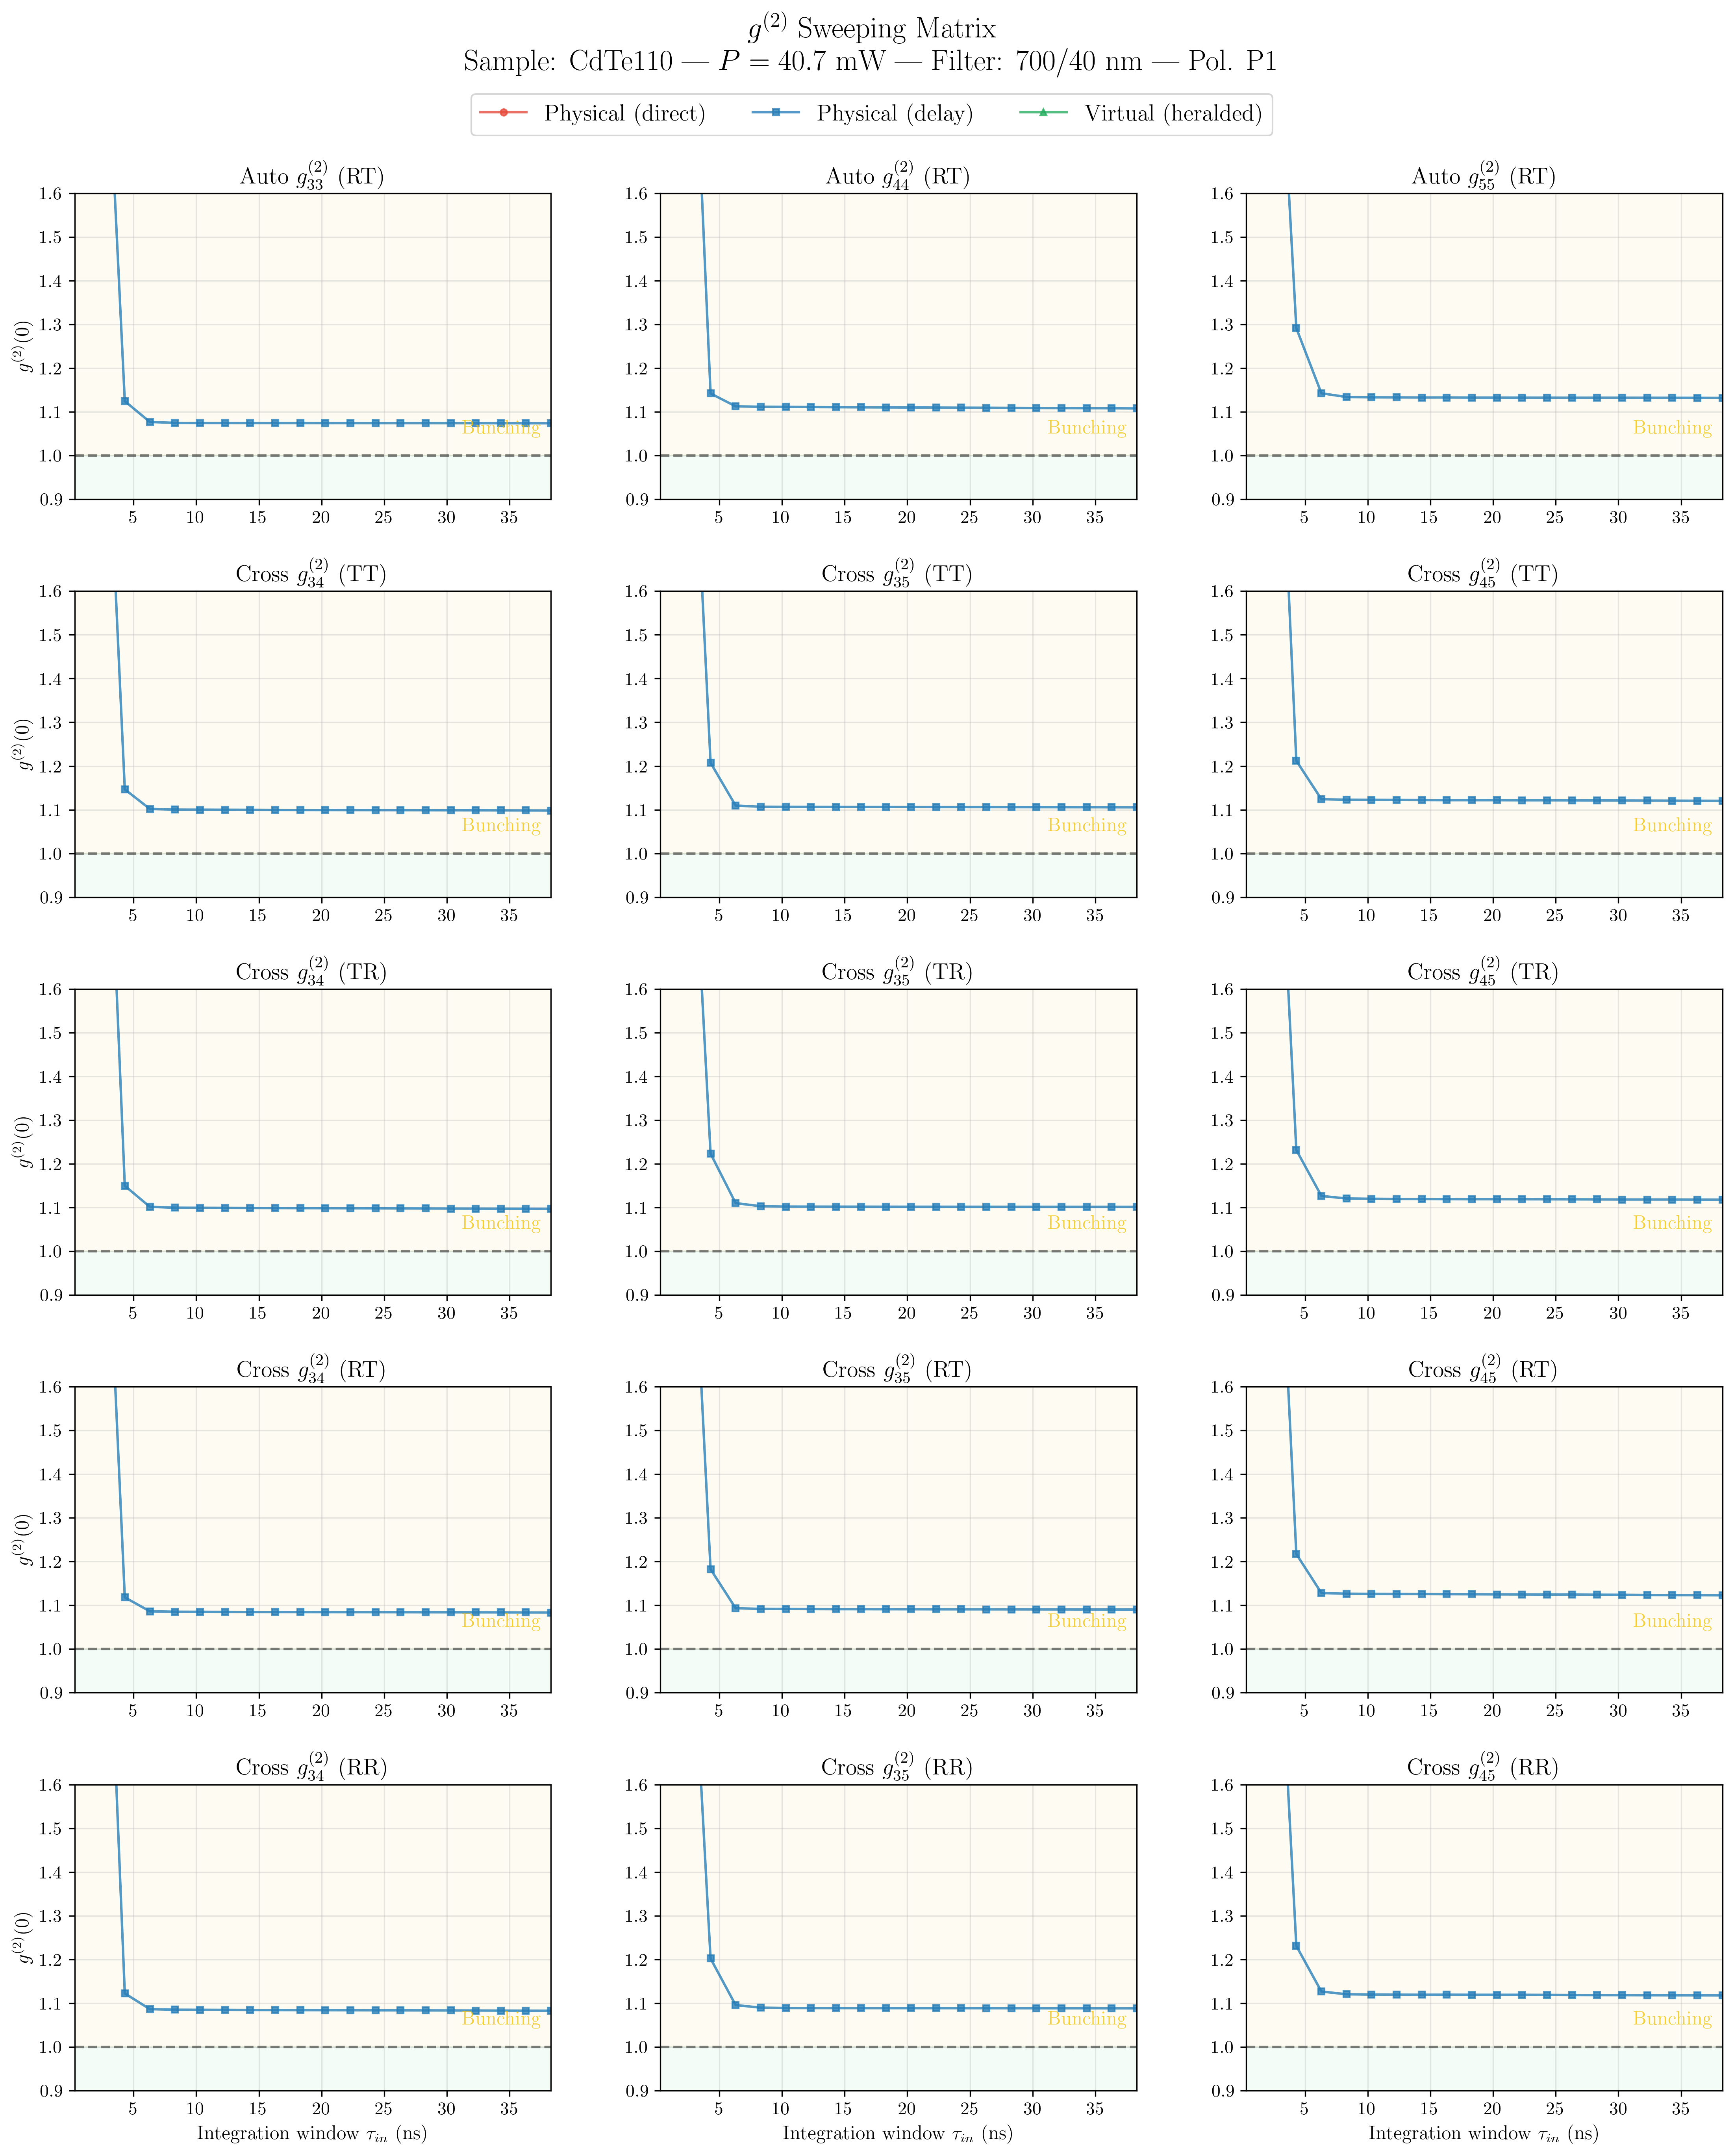

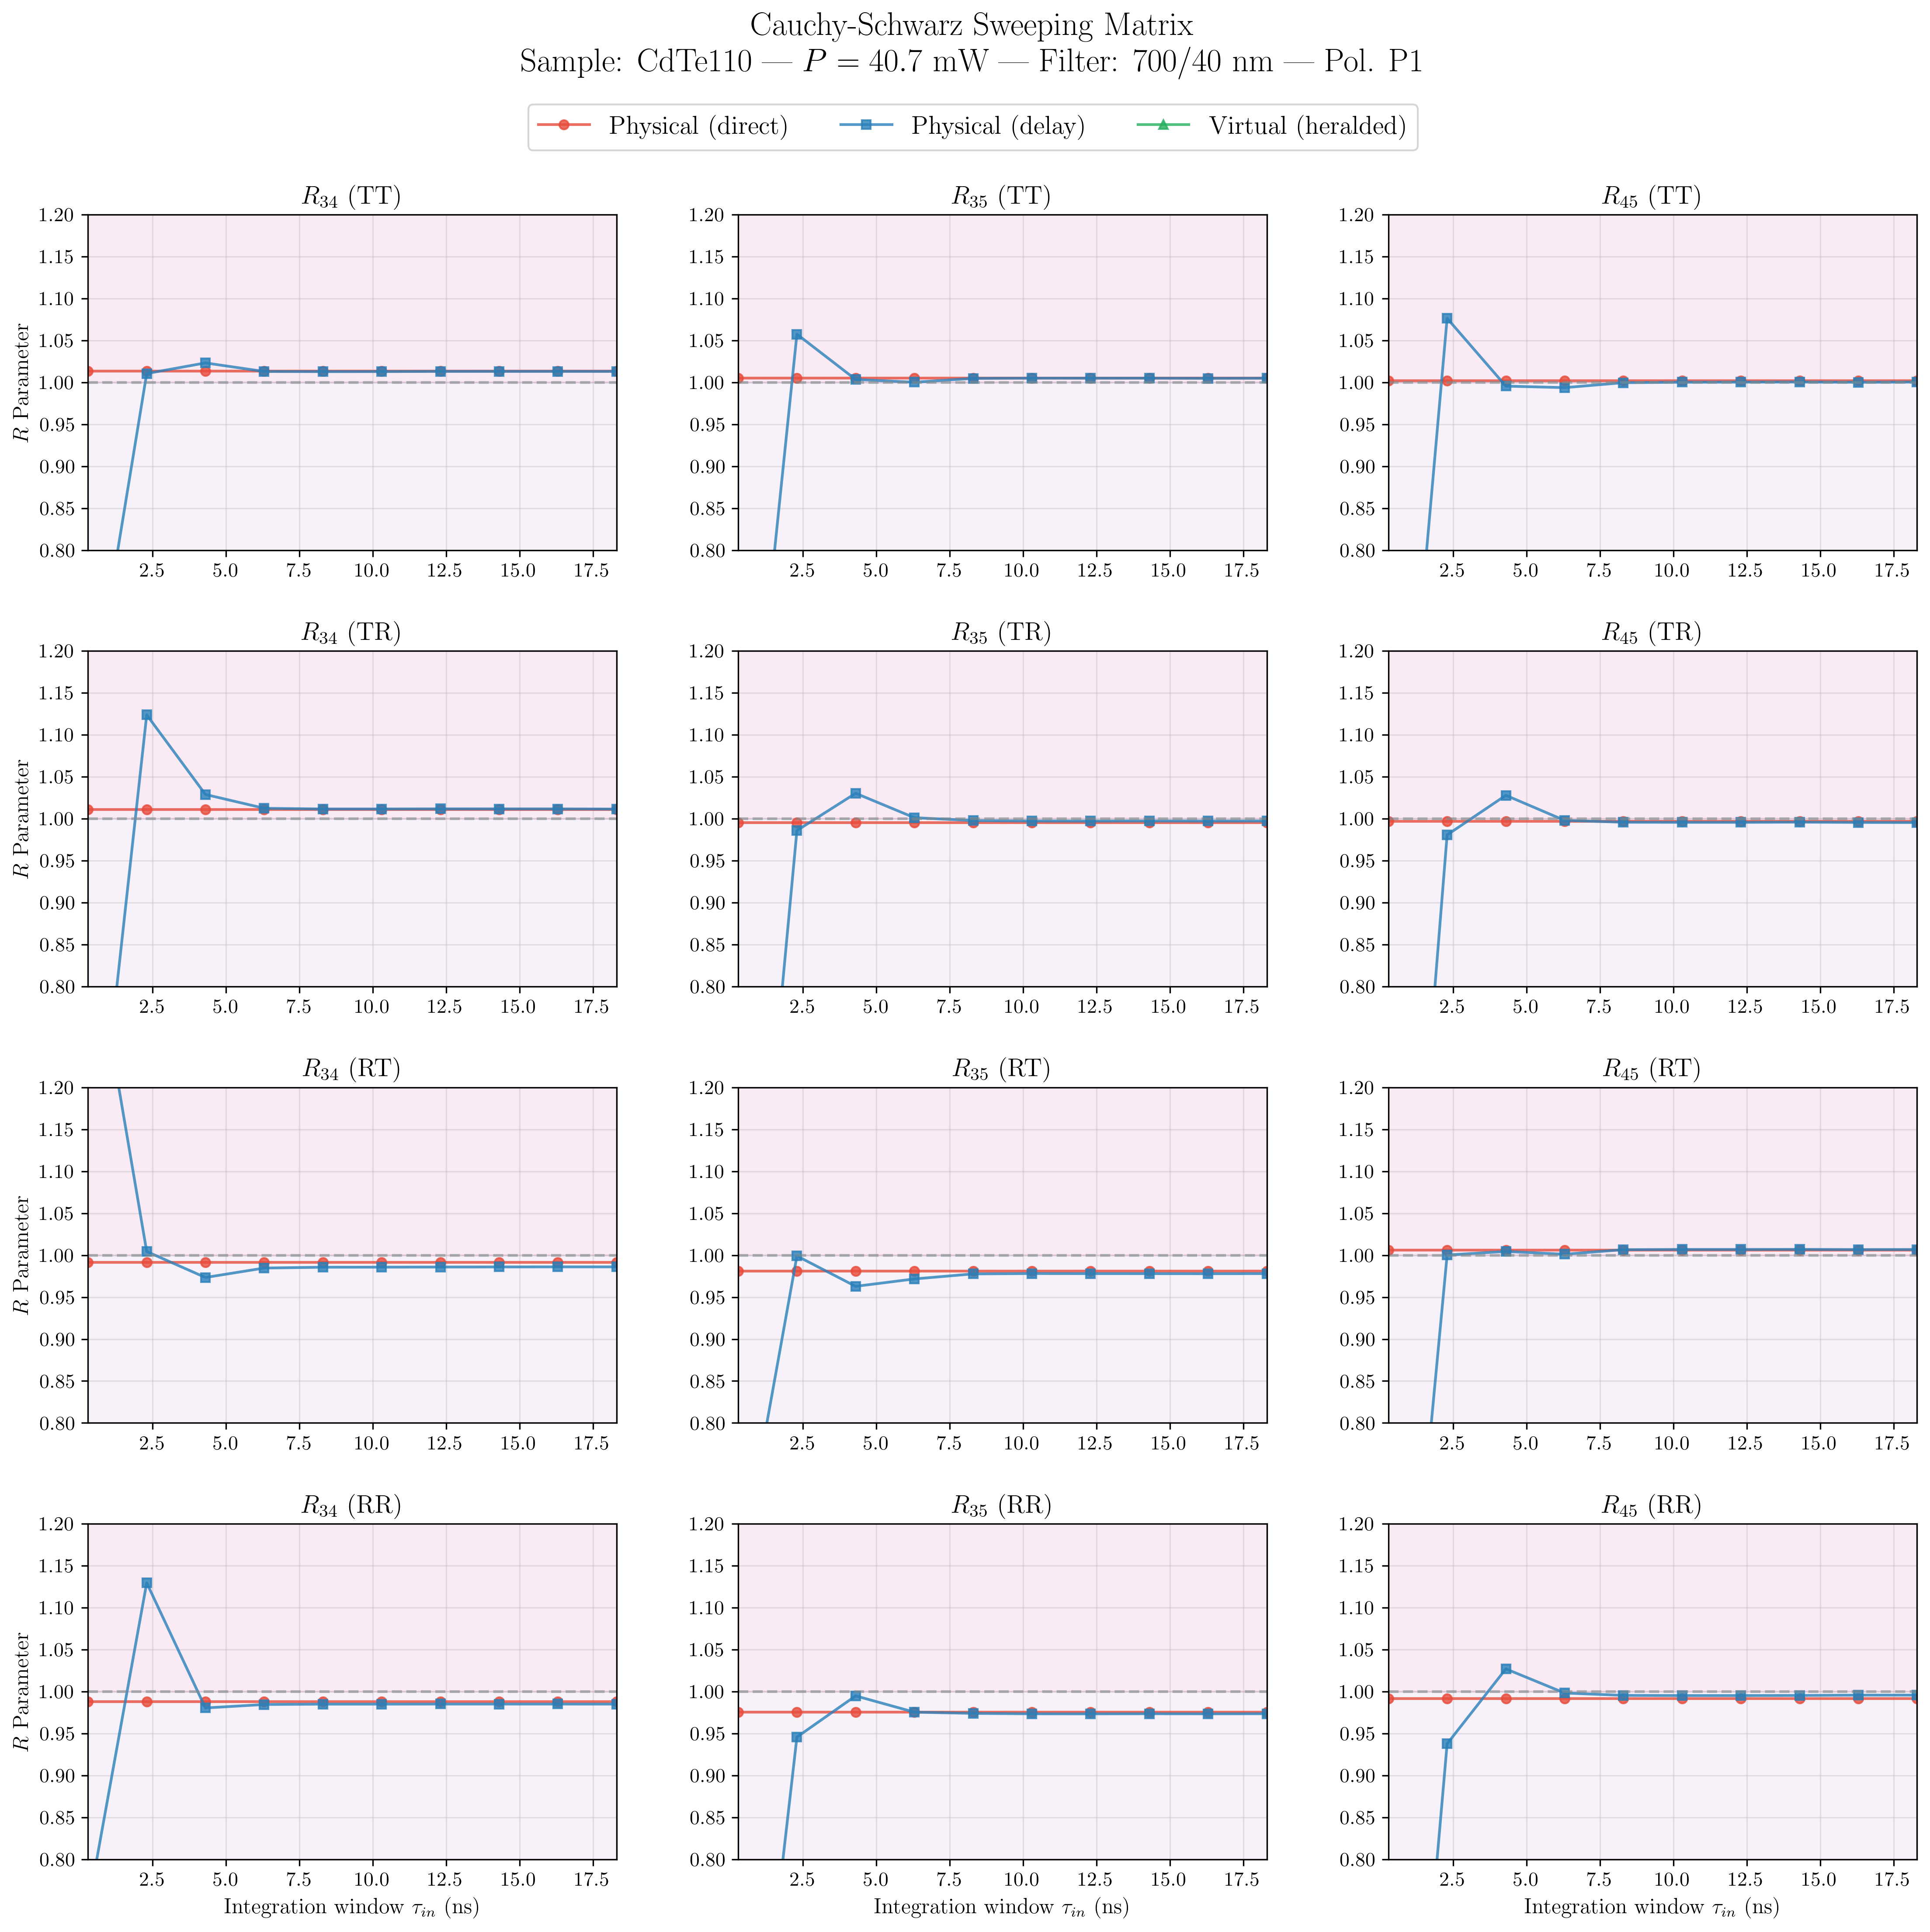

In [4]:
for r in runs:
    print("="*90)
    print("RUN:", r.short_tag())
    v = GridVisualizer(r, show_details=False)
    v.plot_coherence(time_window_ns=5, xlim=200, integration_window_ns=10)
    v.plot_g2(methods=['direct', 'delay', 'heralded'], tau_min=0.3, tau_max=40, step=2.0)
    v.plot_R(methods=['direct', 'delay', 'heralded'], tau_min=0.3, tau_max=20, step=2.0)

## 4. Cross-dataset comparison

All runs overlaid on the same axes. Physical `direct` $g^{(2)}$ and Cauchy–Schwarz $R$ — the cleanest way to
see the effect of the filter / polarisation.

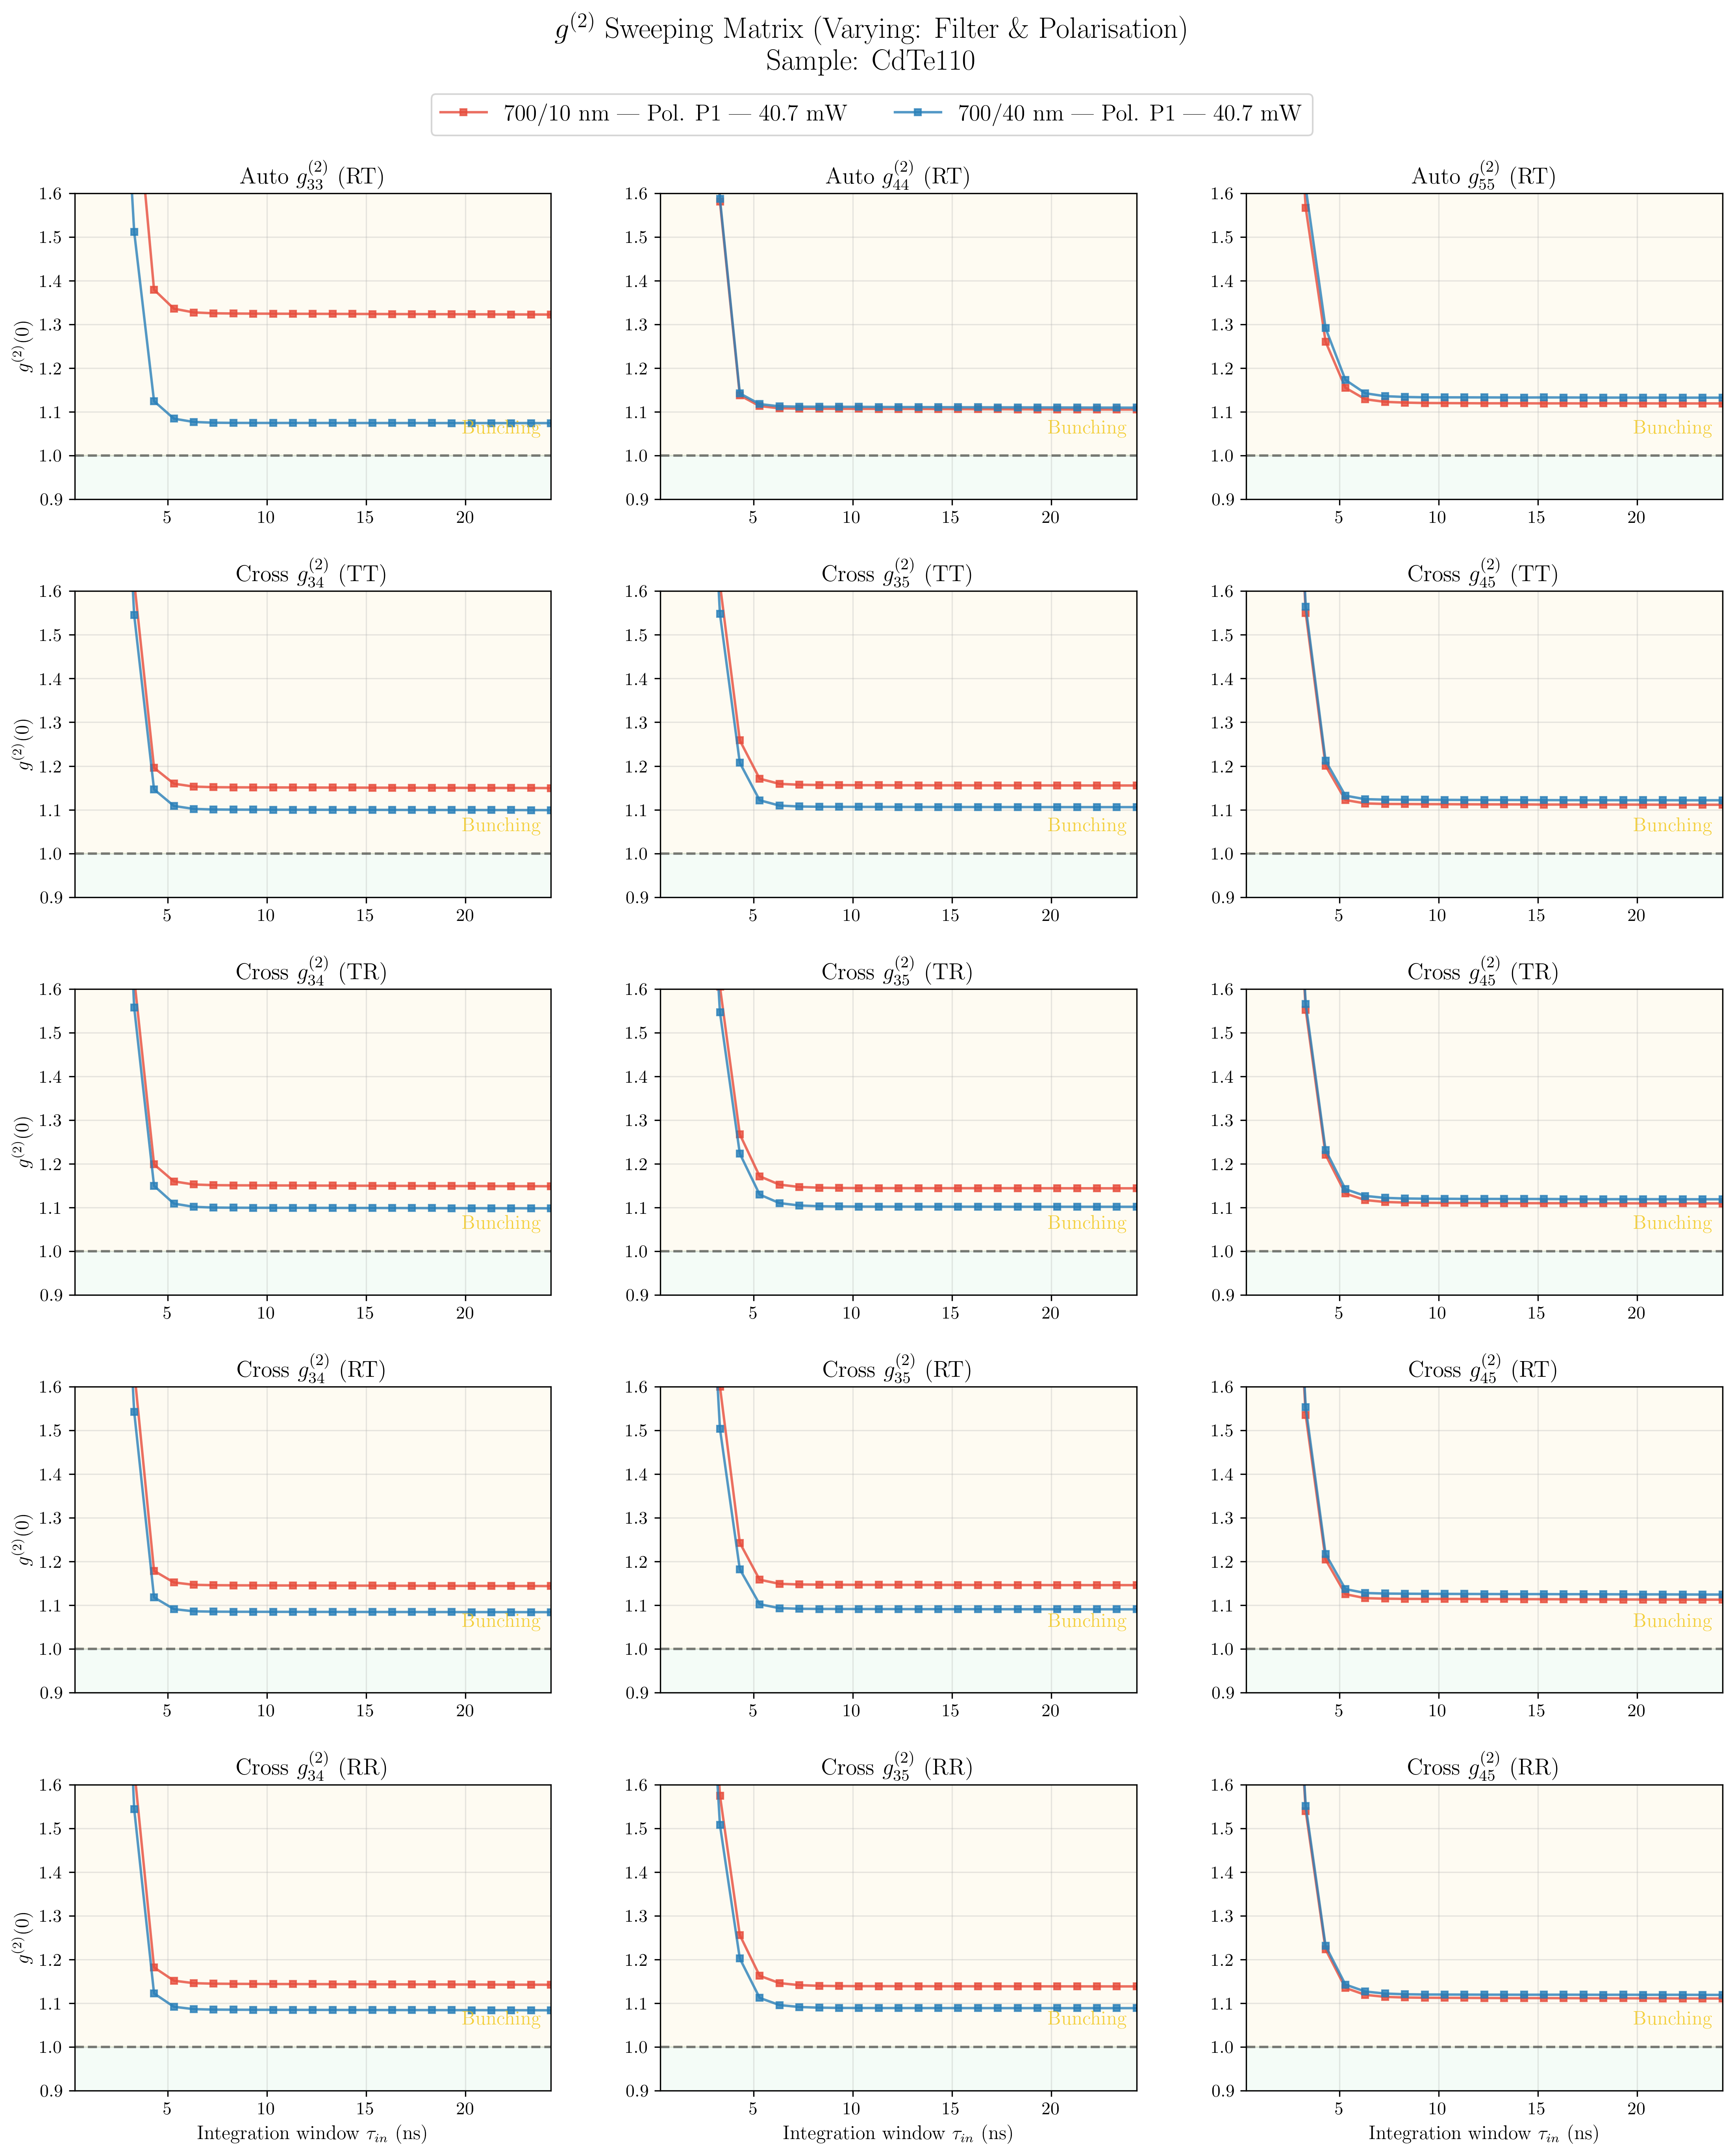

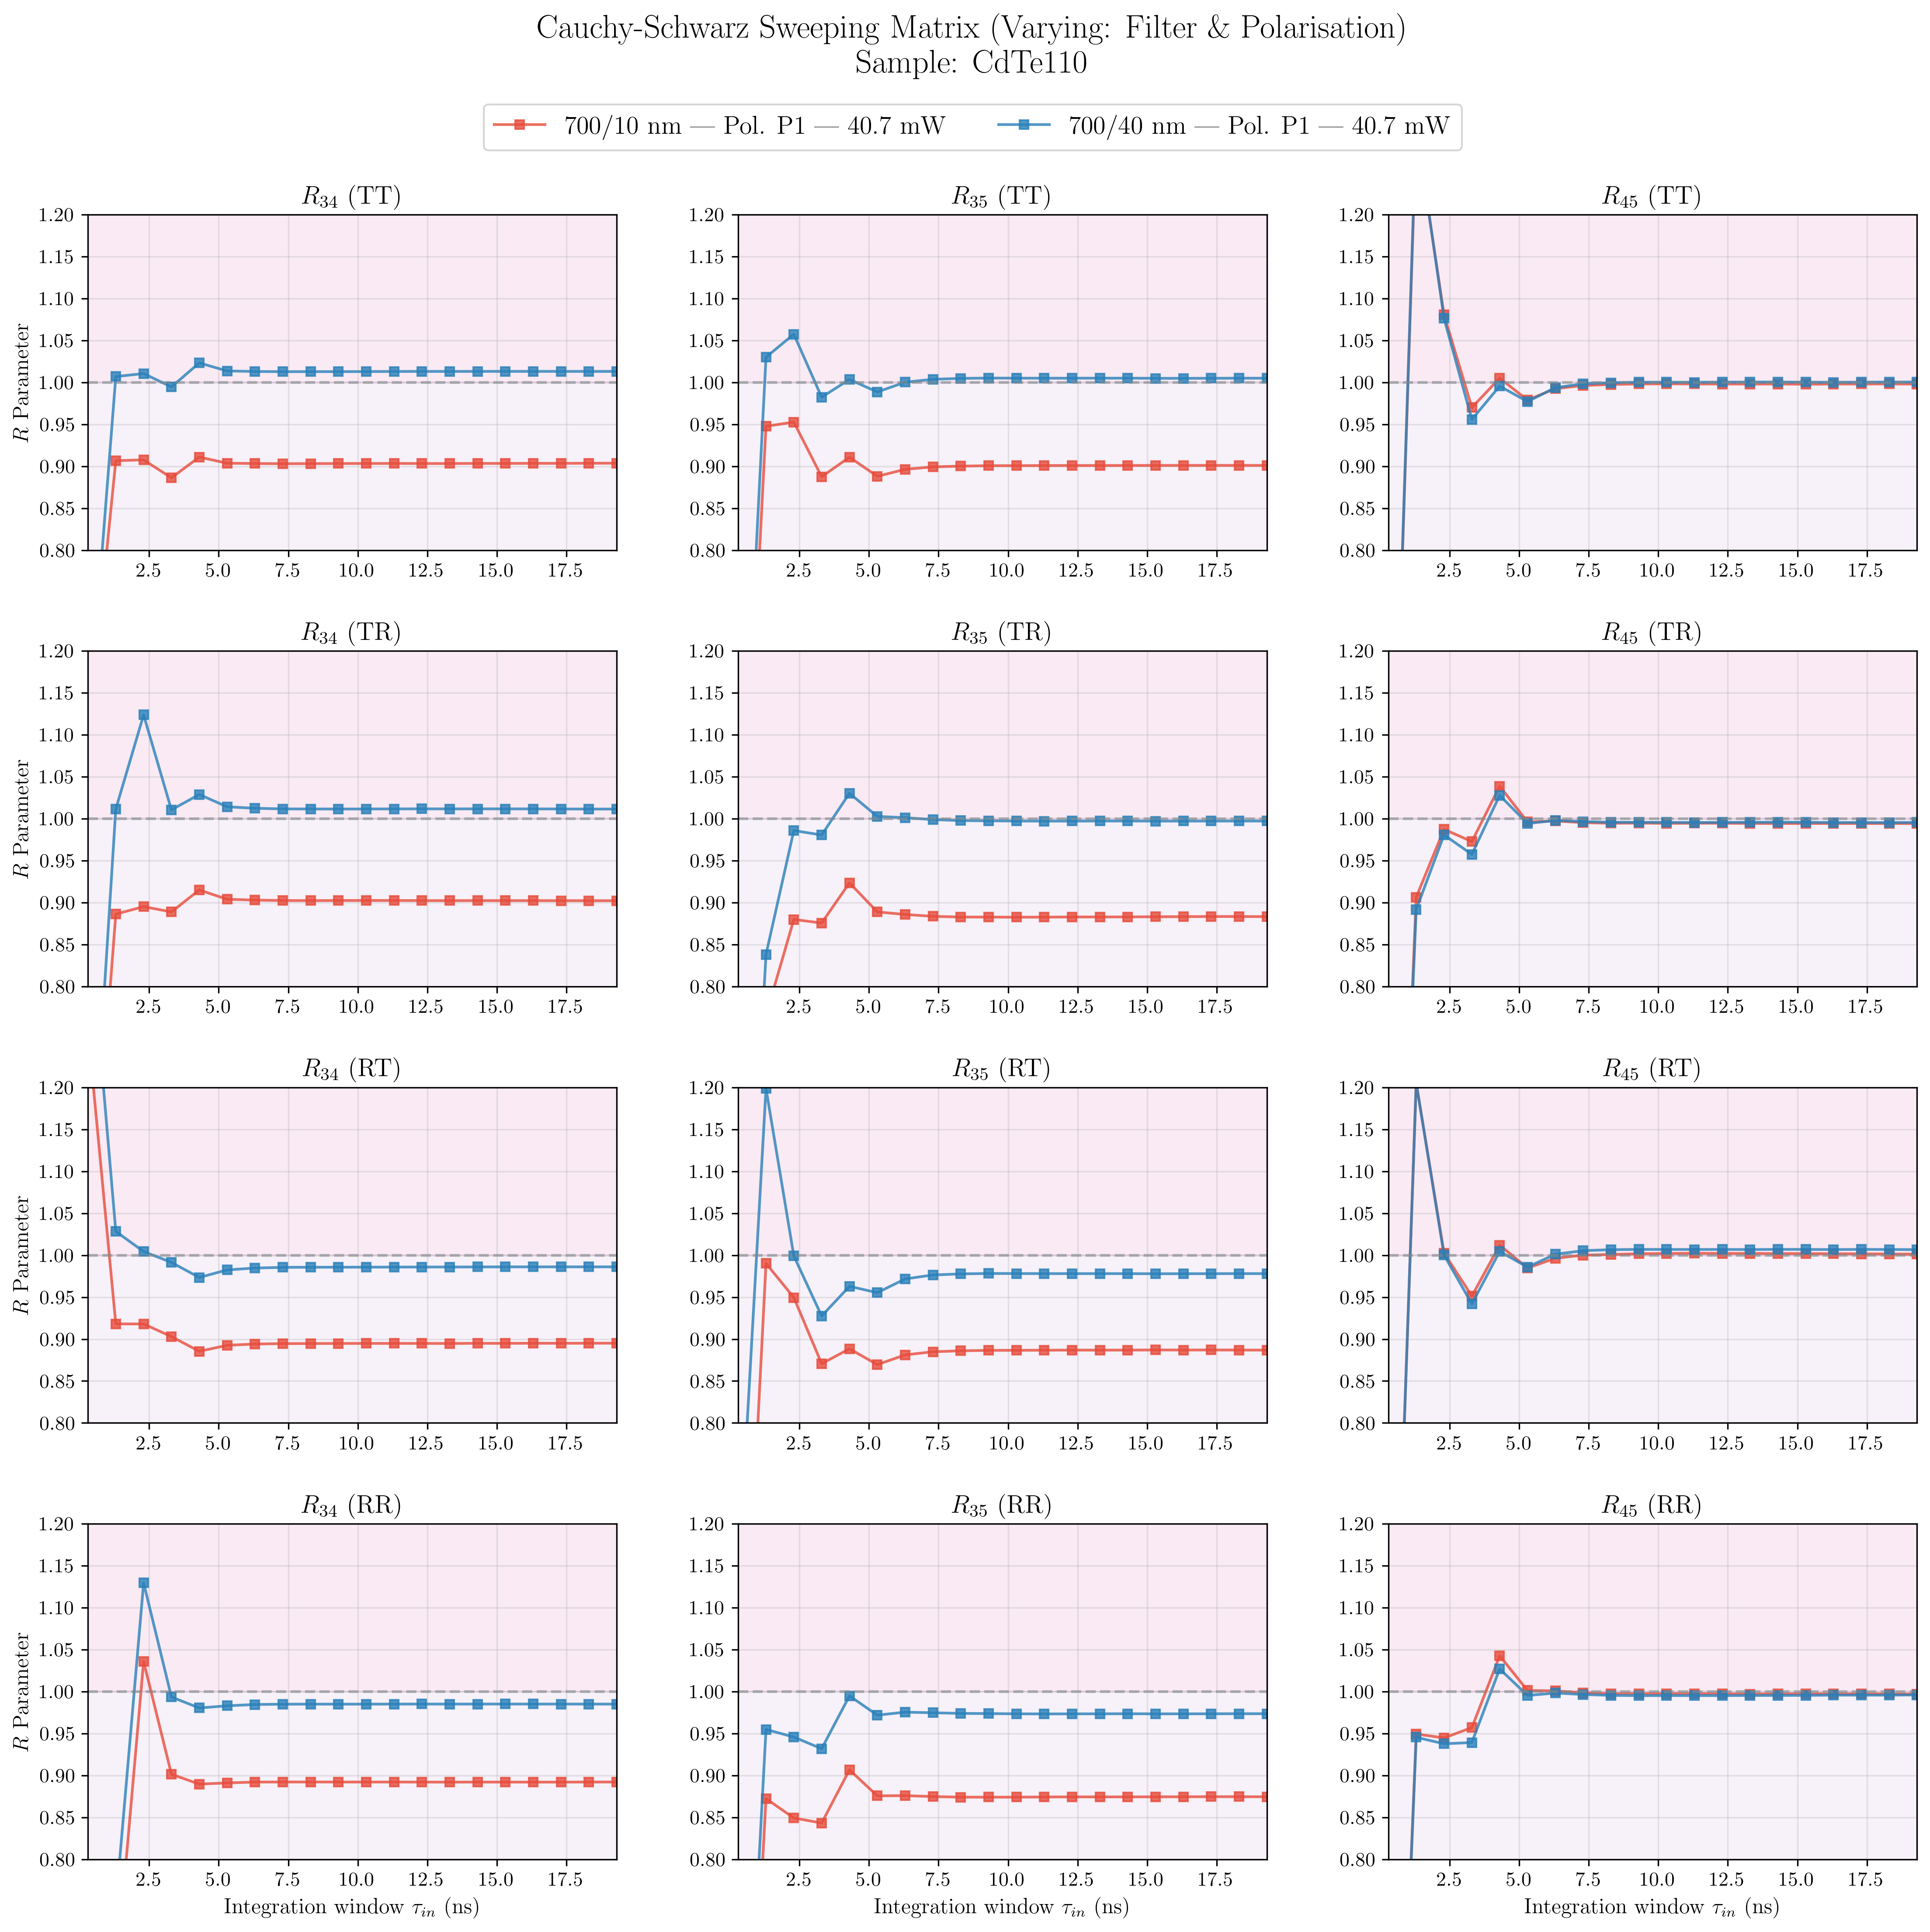

(<Figure size 5400x4800 with 12 Axes>,
 array([[<Axes: title={'center': '$R_{34}$ (TT)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (TT)'}>,
         <Axes: title={'center': '$R_{45}$ (TT)'}>],
        [<Axes: title={'center': '$R_{34}$ (TR)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (TR)'}>,
         <Axes: title={'center': '$R_{45}$ (TR)'}>],
        [<Axes: title={'center': '$R_{34}$ (RT)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (RT)'}>,
         <Axes: title={'center': '$R_{45}$ (RT)'}>],
        [<Axes: title={'center': '$R_{34}$ (RR)'}, xlabel='Integration window $\\tau_{in}$ (ns)', ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (RR)'}, xlabel='Integration window $\\tau_{in}$ (ns)'>,
         <Axes: title={'center': '$R_{45}$ (RR)'}, xlabel='Integration window $\\tau_{in}$ (ns)'>]],
       dtype=object))

In [5]:
comparator = GridVisualizer(runs, comparison_variable="Filter \\& Polarisation")

comparator.plot_g2(methods=['delay'], tau_min=0.3, tau_max=25, step=1.0)
comparator.plot_R(methods=['delay'], tau_min=0.3, tau_max=20, step=1.0)